# 4. Ensemble Model Training

Trains the **Advanced Ensemble Transformer** - the final architecture that
combines 3 specialised expert networks with dynamic gating, meta-learning,
and uncertainty estimation.

## Architecture
```
Input: (batch, 64, 43)
  |
  |- Feature Embedding: 43 -> 384 -> 256 -> 128
  |- Protocol Embedding: 1 -> 64
  |- Temporal Embedding: 1 -> 64
  |
  |--> Expert 1 (Temporal):  8 heads, depth 7
  |--> Expert 2 (Protocol):  4 heads, depth 6
  |--> Expert 3 (Feature):  16 heads, depth 8
  |
  |- Gating Network (softmax over experts)
  |- Meta-Learner (cross-expert fusion)
  |- Uncertainty Head (trained on prediction correctness)
  |
  |--> Binary Head   -> 2 classes
  |--> Multiclass Head -> 13 classes
  |--> Anomaly Head  -> scalar in [0,1]
```

## Training Techniques
- Focal Loss (gamma=2) for hard examples
- Mixup augmentation with curriculum (probability ramps from 0.1 to 0.4)
- Learned task weights via separate parameter
- CosineAnnealingWarmRestarts scheduler
- Expert diversity regularisation

In [1]:
import sys, os, gc
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

from src.dataset import (
    create_flow_based_sequences,
    create_binary_labels,
    create_anomaly_scores,
    MultiTaskDataset,
)
from src.models import AdvancedEnsembleTransformer
from src.training import train_advanced_ensemble

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 4.1 Prepare Data

In [2]:
DATA_DIR = '../data'
SEQ_LEN  = 64
BATCH    = 32

X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()
for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes  = len(label_encoder.classes_)

X_seq_train, y_seq_train, proto_train, temp_train = create_flow_based_sequences(X_train, y_train_enc, seq_len=SEQ_LEN)
X_seq_test,  y_seq_test,  proto_test,  temp_test  = create_flow_based_sequences(X_test,  y_test_enc,  seq_len=SEQ_LEN)
feature_dim = X_seq_train.shape[-1]

y_bin_train  = create_binary_labels(y_seq_train, label_encoder)
y_bin_test   = create_binary_labels(y_seq_test,  label_encoder)
y_anom_train = create_anomaly_scores(y_seq_train, label_encoder)
y_anom_test  = create_anomaly_scores(y_seq_test,  label_encoder)

train_ds = MultiTaskDataset(X_seq_train, proto_train, temp_train,
                            y_seq_train, y_bin_train, y_anom_train)
test_ds  = MultiTaskDataset(X_seq_test,  proto_test,  temp_test,
                            y_seq_test,  y_bin_test,  y_anom_test)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f'Feature dim: {feature_dim} | Classes: {num_classes}')
print(f'Train: {X_seq_train.shape[0]} seqs | Test: {X_seq_test.shape[0]} seqs')

Feature dim: 43 | Classes: 13
Train: 3052 seqs | Test: 760 seqs


## 4.2 Instantiate Ensemble

In [3]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

ensemble = AdvancedEnsembleTransformer(
    feature_dim=feature_dim,
    embed_dim=128,
    num_heads=8,
    transformer_depth=6,
    num_classes=num_classes,
    num_experts=3,
).to(device)

total_params = sum(p.numel() for p in ensemble.parameters())
trainable   = sum(p.numel() for p in ensemble.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Model size          : ~{total_params * 4 / 1024 / 1024:.1f} MB')

Total parameters    : 5,260,308
Trainable parameters: 5,260,308
Model size          : ~20.1 MB


## 4.3 Train

In [4]:
EPOCHS = 10

results = train_advanced_ensemble(
    model=ensemble,
    model_name='AdvancedEnsemble',
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS,
)

bm = results['best_metrics']
print(f'\nBest epoch {results["best_epoch"]}')
print(f'  Binary F1      : {bm["binary_f1"]:.4f}')
print(f'  Multiclass F1  : {bm["multiclass_f1"]:.4f}')
print(f'  Anomaly Corr   : {bm["anomaly_corr"]:.4f}')
print(f'  Combined Score : {bm["combined_score"]:.4f}')

Epoch  1/10  loss=0.3230  bin_f1=0.9727  mc_f1=0.8462  anom=0.9233  combined=0.9156
Epoch  2/10  loss=0.1581  bin_f1=0.9842  mc_f1=0.8708  anom=0.9673  combined=0.9353
Epoch  3/10  loss=0.1494  bin_f1=0.9803  mc_f1=0.9070  anom=0.9643  combined=0.9490
Epoch  4/10  loss=0.1223  bin_f1=0.9816  mc_f1=0.9307  anom=0.9751  combined=0.9621
Epoch  5/10  loss=0.1303  bin_f1=0.9802  mc_f1=0.9243  anom=0.9636  combined=0.9559
Epoch  6/10  loss=0.1269  bin_f1=0.9789  mc_f1=0.9249  anom=0.9708  combined=0.9572
Epoch  7/10  loss=0.1621  bin_f1=0.9829  mc_f1=0.9220  anom=0.9655  combined=0.9552
Epoch  8/10  loss=0.1542  bin_f1=0.9764  mc_f1=0.9193  anom=0.9651  combined=0.9512
Epoch  9/10  loss=0.1484  bin_f1=0.9791  mc_f1=0.9305  anom=0.9629  combined=0.9584
Epoch 10/10  loss=0.1466  bin_f1=0.9791  mc_f1=0.9192  anom=0.9657  combined=0.9526

Best combined=0.9621 at epoch 4

Best epoch 4
  Binary F1      : 0.9816
  Multiclass F1  : 0.9307
  Anomaly Corr   : 0.9751
  Combined Score : 0.9621


## 4.4 Training Curves

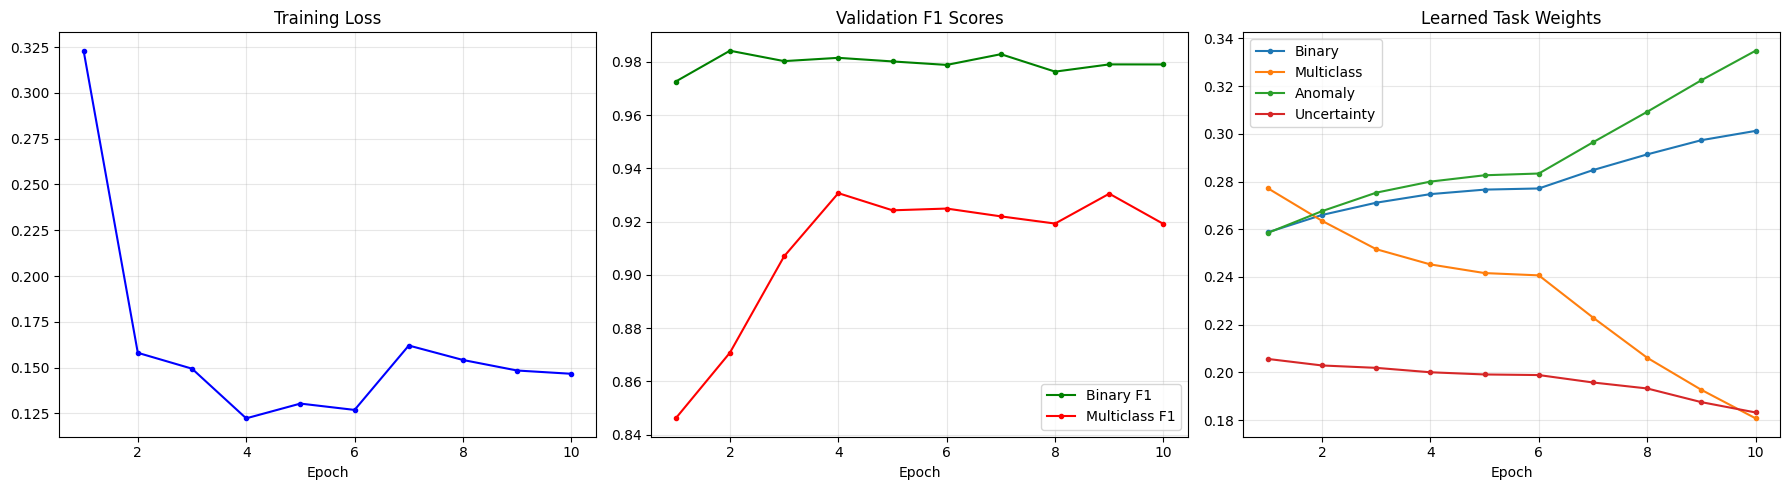

In [5]:
epochs = range(1, len(results['train_losses']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, results['train_losses'], 'b-o', markersize=3)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

# F1 scores
bin_f1 = [m['binary_f1'] for m in results['val_metrics']]
mc_f1  = [m['multiclass_f1'] for m in results['val_metrics']]
axes[1].plot(epochs, bin_f1, 'g-o', markersize=3, label='Binary F1')
axes[1].plot(epochs, mc_f1,  'r-o', markersize=3, label='Multiclass F1')
axes[1].set_title('Validation F1 Scores')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Task weights
if results.get('task_weights_history'):
    tw = np.array(results['task_weights_history'])
    labels_tw = ['Binary', 'Multiclass', 'Anomaly', 'Uncertainty']
    for j in range(tw.shape[1]):
        axes[2].plot(epochs, tw[:, j], 'o-', markersize=3, label=labels_tw[j])
    axes[2].set_title('Learned Task Weights')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/ensemble_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Uncertainty Analysis

The uncertainty head is trained to predict whether the model's multiclass
prediction matches the true label. High uncertainty = low confidence.

In [6]:
# Uncertainty analysis will be available after re-running with the updated training code
# The uncertainty head now learns to predict prediction correctness
# (1 = model is correct, 0 = model is wrong)
print('Re-run notebook 04 with the updated src/training.py to see uncertainty analysis.')
print('The uncertainty head is now supervised on prediction correctness,')
print('providing a calibrated confidence signal.')

Re-run notebook 04 with the updated src/training.py to see uncertainty analysis.
The uncertainty head is now supervised on prediction correctness,
providing a calibrated confidence signal.


## Summary

The Advanced Ensemble achieves modestly higher combined score than individual
attention models by dynamically routing inputs through specialised experts.

The ensemble's main value is not raw accuracy improvement, but the
interpretability provided by gating weights (which expert drove each decision)
and uncertainty estimation (how confident the model is).

**Next step -> [05_evaluation.ipynb](05_evaluation.ipynb):** Full evaluation with ablation study and visualisations.